# EDA — Demande & Tarification dynamique (Mariam Rabah)

**Statut : PROTOTYPE.** Ce notebook analyse un jeu de données **synthétique**
(généré par `src/data_synthetic.py`), pas de vraies données SmartTaxi/Tunis.
Objectif : valider tout le pipeline (features → baseline → XGBoost → API)
et documenter la méthode, en attendant l'accès à un vrai flux du backend
ou à un dataset public (NYC Taxi Trip Data, Uber Movement).

**Reproductibilité.** Le dataset provient de
`src.data_synthetic.load_reference_dataset()`, qui utilise une fenêtre
temporelle **figée** (`config.SYNTHETIC_DATA`) et une graine aléatoire
fixe. Relancer ce notebook, aujourd'hui ou dans six mois, produit
exactement les mêmes chiffres et les mêmes graphiques.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import SYNTHETIC_DATA
from src.data_synthetic import load_reference_dataset
from src.model_baseline import BaselineModel
from src.model_xgboost import DemandXGBModel
from src.features import build_feature_frame, feature_columns, TARGET

plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.width", 120)

df = load_reference_dataset()
print(f"Fenêtre figée : {SYNTHETIC_DATA.reference_end - pd.Timedelta(days=SYNTHETIC_DATA.history_days)} -> {SYNTHETIC_DATA.reference_end}")
print(f"{len(df)} lignes, {df['zone_id'].nunique()} zones, seed={SYNTHETIC_DATA.seed}")
df.head()

Fenêtre figée : 2026-08-18 00:00:00+00:00 -> 2026-09-01 00:00:00+00:00
3365 lignes, 5 zones, seed=42


,zone_id,timestamp,hour,weekday,is_weekend,demand,supply
0,snx1rs,2026-08-18 00:00:00+00:00,0,1,False,5.57,4.41
1,snx1zv,2026-08-18 00:00:00+00:00,0,1,False,6.98,5.28
2,snx38g,2026-08-18 00:00:00+00:00,0,1,False,8.62,10.55
3,snx30d,2026-08-18 00:00:00+00:00,0,1,False,6.01,3.97
4,snx3fc,2026-08-18 00:00:00+00:00,0,1,False,11.35,8.55


## 1. Vue d'ensemble du dataset

In [2]:
print(df.dtypes)
print()
print(df[["demand", "supply"]].describe())

zone_id                       str
timestamp     datetime64[us, UTC]
hour                        int64
weekday                     int64
is_weekend                   bool
demand                    float64
supply                    float64
dtype: object

            demand       supply
count  3365.000000  3365.000000
mean     18.016146    17.238315
std      10.661740    11.199174
min       0.000000     0.000000
25%      10.260000     9.070000
50%      15.050000    14.210000
75%      23.960000    22.760000
max      57.270000    73.190000


**Limite connue (à garder en tête pour toute la suite) :** 14 jours
d'historique, 5 zones de démonstration. C'est volontairement court —
suffisant pour valider le pipeline, insuffisant pour évaluer une vraie
saisonnalité (effet mensuel, jours fériés, événements) qui demanderait
plusieurs mois de vraies données.

## 2. Distribution de la demande par heure de la journée

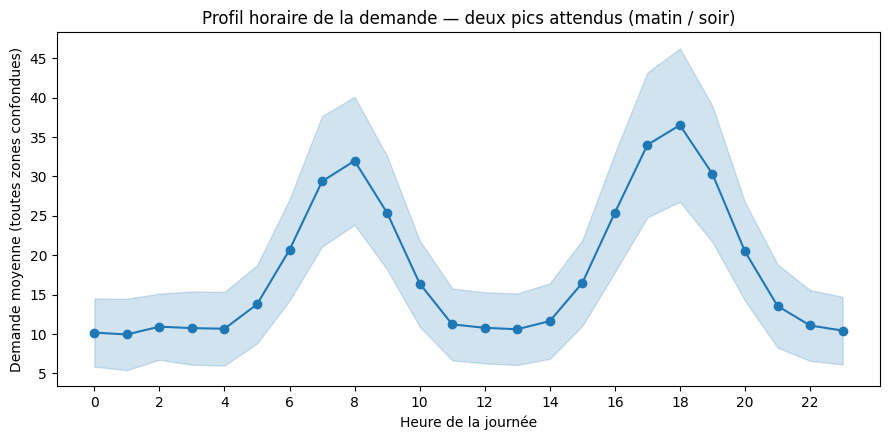

In [ ]:
hourly = df.groupby("hour")["demand"].agg(["mean", "std"])

fig, ax = plt.subplots()
ax.plot(hourly.index, hourly["mean"], marker="o", color="#1f77b4")
ax.fill_between(
    hourly.index,
    hourly["mean"] - hourly["std"],
    hourly["mean"] + hourly["std"],
    alpha=0.2,
    color="#1f77b4",
)
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Demande moyenne (toutes zones confondues)")
ax.set_title("Profil horaire de la demande — deux pics attendus (matin / soir)")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

On retrouve bien les deux pics injectés par le générateur synthétique
(~8h et ~18h) — c'est cohérent avec ce qu'on attend d'une vraie ville, mais
**c'est une confirmation que le générateur fait ce qu'on lui a demandé,
pas une preuve sur la demande réelle à Tunis.**

## 3. Distribution de la demande par zone

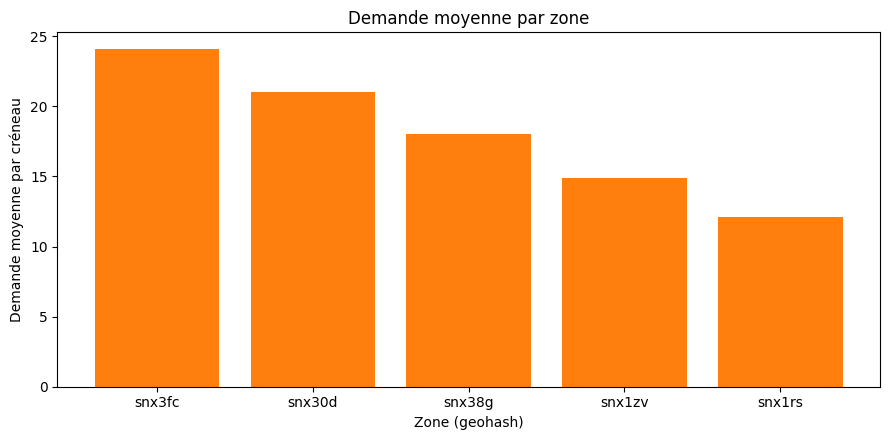

,mean,sum,count
zone_id,,,
snx3fc,24.075572,16202.86,673
snx30d,21.001649,14134.11,673
snx38g,18.014027,12123.44,673
snx1zv,14.917845,10039.71,673
snx1rs,12.071634,8124.21,673


In [4]:
zone_stats = df.groupby("zone_id")["demand"].agg(["mean", "sum", "count"]).sort_values("mean", ascending=False)

fig, ax = plt.subplots()
ax.bar(zone_stats.index, zone_stats["mean"], color="#ff7f0e")
ax.set_xlabel("Zone (geohash)")
ax.set_ylabel("Demande moyenne par créneau")
ax.set_title("Demande moyenne par zone")
plt.tight_layout()
plt.show()

zone_stats

Les 5 zones de démonstration ont des niveaux de demande différents par
construction (`zone_factor` dans le générateur). En production, ce
classement doit venir des vraies données et sera probablement bien plus
fin (des dizaines/centaines de zones geohash, pas 5).

## 4. Effet week-end / jour de semaine

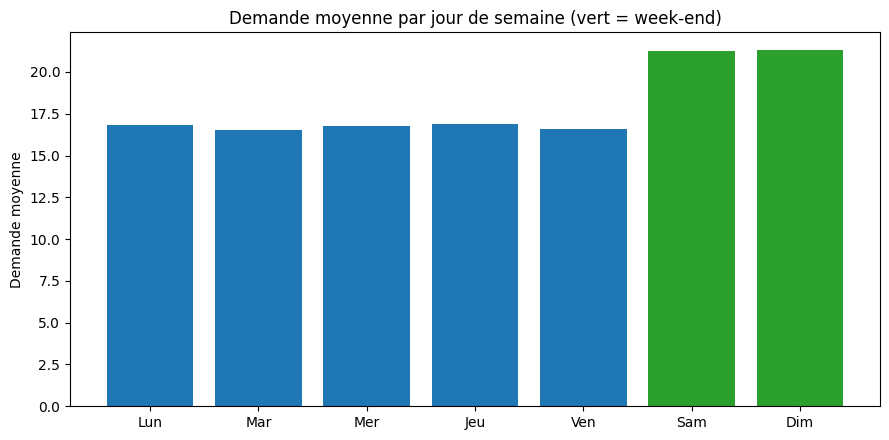

In [5]:
weekday_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
weekday_stats = df.groupby("weekday")["demand"].mean().reindex(range(7))

fig, ax = plt.subplots()
colors = ["#1f77b4"] * 5 + ["#2ca02c"] * 2  # semaine vs week-end
ax.bar(weekday_labels, weekday_stats.values, color=colors)
ax.set_ylabel("Demande moyenne")
ax.set_title("Demande moyenne par jour de semaine (vert = week-end)")
plt.tight_layout()
plt.show()

## 5. Carte heure × zone (heatmap)

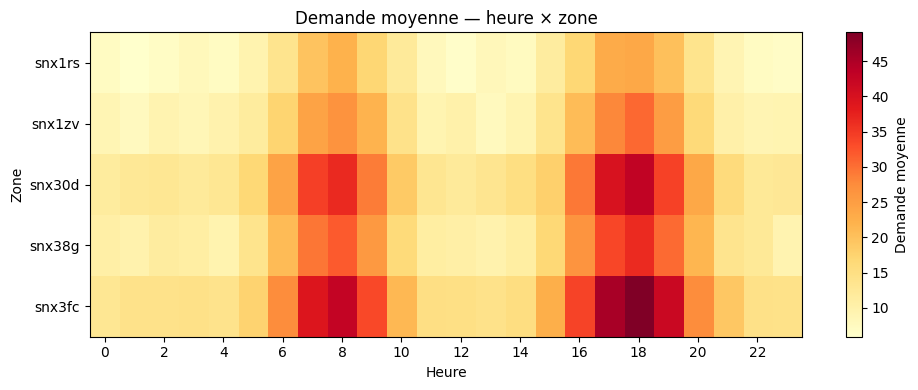

In [6]:
pivot = df.pivot_table(index="zone_id", columns="hour", values="demand", aggfunc="mean")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel("Heure")
ax.set_ylabel("Zone")
ax.set_title("Demande moyenne — heure × zone")
fig.colorbar(im, ax=ax, label="Demande moyenne")
plt.tight_layout()
plt.show()

## 6. Baseline vs XGBoost

Split **temporel** (les dernières lignes chronologiques servent de test),
pas un split aléatoire — pour éviter toute fuite d'information (le modèle
ne doit jamais "voir" le futur pendant l'entraînement). Comparaison
demandée explicitement par le Guide d'intégration §11.

In [7]:
ordered = df.sort_values("timestamp")
cutoff = int(len(ordered) * 0.8)

baseline = BaselineModel().fit(ordered.iloc[:cutoff])
baseline_preds_all = ordered.apply(
    lambda r: baseline.predict_one(r.zone_id, r.hour, r.weekday), axis=1
)

xgb_model = DemandXGBModel()
metrics = xgb_model.fit(ordered, baseline_predictions=baseline_preds_all)

print(metrics.summary())

MAE=2.83 (baseline=3.13, gain=0.30 soit 9.6%) RMSE=3.57 R2=0.899


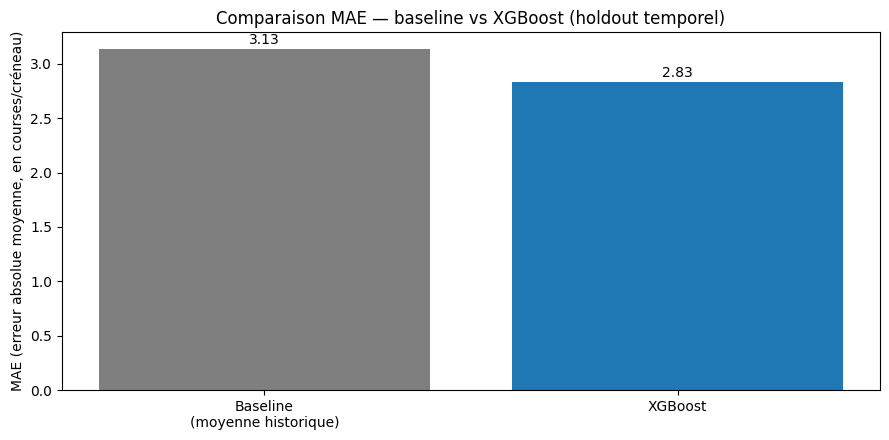

Gain XGBoost vs baseline : 9.6% de MAE en moins


In [8]:
fig, ax = plt.subplots()
bars = ax.bar(["Baseline\n(moyenne historique)", "XGBoost"], [metrics.baseline_mae, metrics.mae],
              color=["#7f7f7f", "#1f77b4"])
ax.set_ylabel("MAE (erreur absolue moyenne, en courses/créneau)")
ax.set_title("Comparaison MAE — baseline vs XGBoost (holdout temporel)")
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", (bar.get_x() + bar.get_width() / 2, height),
                textcoords="offset points", xytext=(0, 4), ha="center")
plt.tight_layout()
plt.show()

gain_pct = 100 * (metrics.baseline_mae - metrics.mae) / metrics.baseline_mae
print(f"Gain XGBoost vs baseline : {gain_pct:.1f}% de MAE en moins")

**Comment lire ce résultat :** sur des données *synthétiques* générées par
une formule connue, XGBoost peut sembler très performant — ce n'est pas
une garantie de performance sur de vraies données, qui seront plus
bruitées et moins régulières. Ce chiffre sert à valider que le pipeline
d'évaluation fonctionne (train/test temporel, calcul MAE/RMSE/R²,
comparaison baseline), pas à annoncer une performance finale.

## 7. Prédit vs réel, et résidus (holdout)

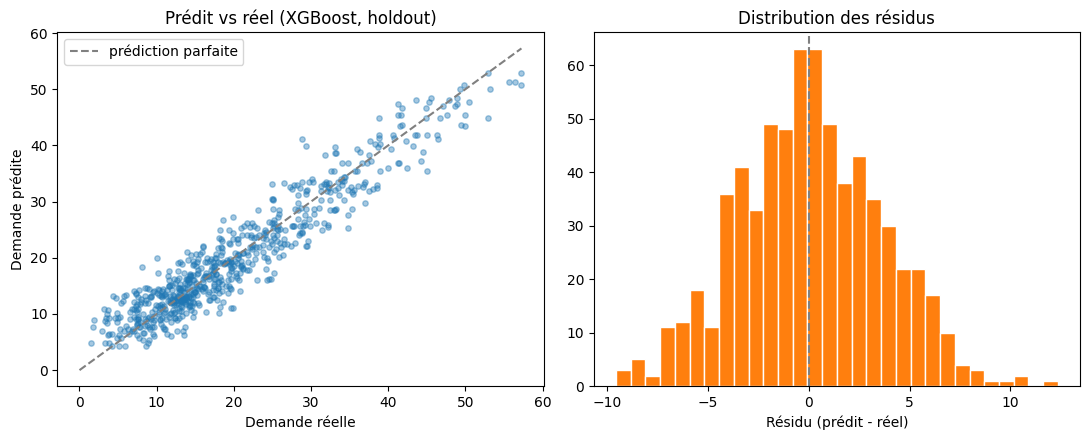

Résidu moyen: 0.050 | écart-type: 3.572


In [9]:
frame = build_feature_frame(ordered)
cols = feature_columns(frame)
X_test = frame[cols].iloc[cutoff:]
y_test = frame[TARGET].iloc[cutoff:]
preds_test = xgb_model._model.predict(X_test)  # accès direct pour l'EDA uniquement

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_test, preds_test, alpha=0.4, s=15, color="#1f77b4")
lims = [0, max(y_test.max(), preds_test.max())]
axes[0].plot(lims, lims, "--", color="gray", label="prédiction parfaite")
axes[0].set_xlabel("Demande réelle")
axes[0].set_ylabel("Demande prédite")
axes[0].set_title("Prédit vs réel (XGBoost, holdout)")
axes[0].legend()

residuals = preds_test - y_test.values
axes[1].hist(residuals, bins=30, color="#ff7f0e", edgecolor="white")
axes[1].axvline(0, color="gray", linestyle="--")
axes[1].set_xlabel("Résidu (prédit - réel)")
axes[1].set_title("Distribution des résidus")

plt.tight_layout()
plt.show()

print(f"Résidu moyen: {residuals.mean():.3f} | écart-type: {residuals.std():.3f}")

Un résidu moyen proche de 0 indique l'absence de biais systématique
(le modèle ne sur/sous-estime pas globalement). À surveiller de près avec
de vraies données : un biais par zone ou par heure de pointe serait un
signal que le modèle doit être corrigé avant tout usage en tarification.

## 8. Limites — à lire avant toute décision d'intégration

- **Données synthétiques, pas réelles.** Tout ce notebook valide le
  *pipeline*, pas la qualité de prédiction sur la vraie demande tunisienne.
  Aucun chiffre ci-dessus ne doit être cité comme performance finale dans
  une soutenance sans le préciser.
- **Historique court (14 jours), 5 zones.** Pas assez pour capturer une
  vraie saisonnalité mensuelle, les jours fériés tunisiens, ou des
  événements ponctuels (matchs, ramadan, rentrée universitaire).
- **Zonage non figé avec l'équipe.** Le découpage geohash (précision 6,
  cf. `config.ZONING`) est une proposition de travail — à valider avec
  Rzeigui (éligibilité), Mohamed Amine (scoring) et Eya (carte) avant
  intégration finale, sous peine d'incohérences entre modules (cf. Guide
  d'intégration §11 et §19).
- **Météo et événements non branchés au modèle.** Le schéma d'API accepte
  `weather` et `is_event_nearby`, mais faute de vraies données ces champs
  ne sont pour l'instant utilisés que par un ajustement heuristique fixe
  (`pricing.apply_context_adjustment`), pas par le modèle XGBoost lui-même.
- **Pas de vraies variables externes** (trafic, jours fériés, prix
  carburant) — à évaluer une fois l'accès aux données du backend confirmé.
- **Confiance heuristique.** `confidence_for()` (baseline et XGBoost) est
  une heuristique simple (quantité d'historique / R² holdout), pas une
  vraie incertitude statistique (ex. intervalle de prédiction). À
  améliorer si le backend a besoin d'une confiance plus rigoureuse.

## 9. Prochaines étapes

1. Remplacer `load_reference_dataset()` par un vrai flux (dataset public
   pour prototyper davantage, puis export backend pour l'intégration
   finale) — voir README §4.
2. Figer le découpage de zone avec l'équipe matching/carte.
3. Reproduire cette même analyse sur les vraies données dès qu'elles sont
   disponibles, et comparer les résultats à ce notebook de référence.
